In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [10]:
np.random.seed(42)

In [16]:
weeks_data = pd.date_range("2022-01-01","2023-12-31",freq="D")

n = len(weeks_data)

# searches_series = np.random.normal(500,25,len(weeks_data))

# trend
trend = np.linspace(500, 700, n)


# yearly seasonality
yearly_seasonality = 100 * np.sin(2 * np.pi * np.arange(n) / 365)

# weekly seasonality
weekly_seasonality = 50 * np.sin(2 * np.pi * np.arange(n) / 7)

# noise
noise = np.random.normal(0,30,n)

searches_series = trend + yearly_seasonality + weekly_seasonality + noise


fake_ts_df = pd.DataFrame({'date':weeks_data,'searches':searches_series})

fake_ts_df

,date,searches
0,2022-01-01,505.875358
1,2022-01-02,511.736075
2,2022-01-03,564.984836
3,2022-01-04,476.601691
4,2022-01-05,517.158119
...,...,...
725,2023-12-27,615.789057
726,2023-12-28,666.150565
727,2023-12-29,666.632514
728,2023-12-30,734.976073


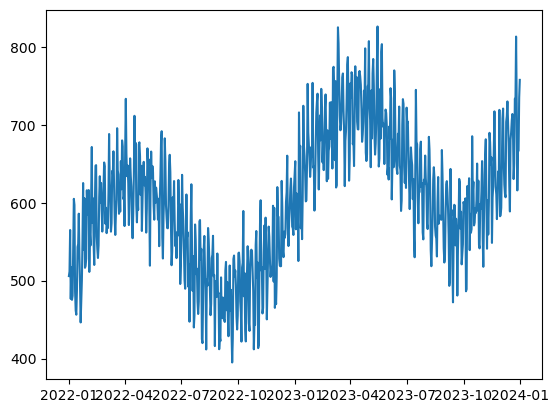

In [ ]:
plt.plot(fake_ts_df['date'],fake_ts_df['searches'])

In [25]:
split_date = "2023-07-01"

train = fake_ts_df[fake_ts_df['date'] < split_date]
test = fake_ts_df[fake_ts_df['date'] >= split_date]

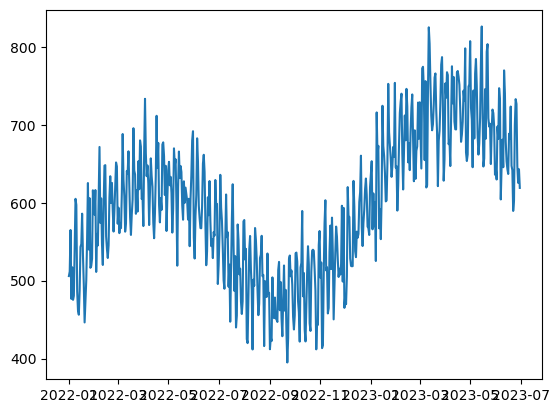

In [26]:
plt.plot(train['date'],train['searches'])

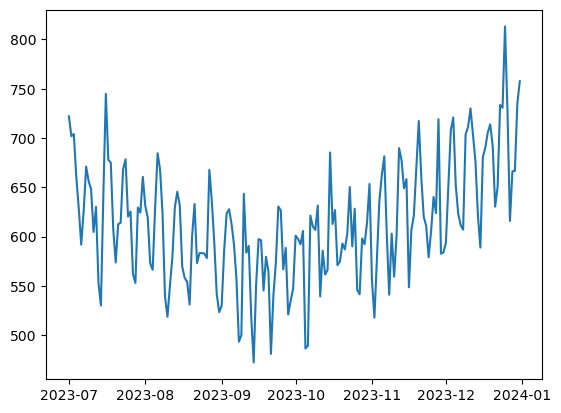

In [27]:
plt.plot(test['date'],test['searches'])

In [32]:
train = train.copy()
train['rolling_mean'] = train['searches'].rolling(window=7).mean()

last_rolling_mean = train['rolling_mean'].dropna().iloc[-1]

test = test.copy()
test['forecast'] = last_rolling_mean

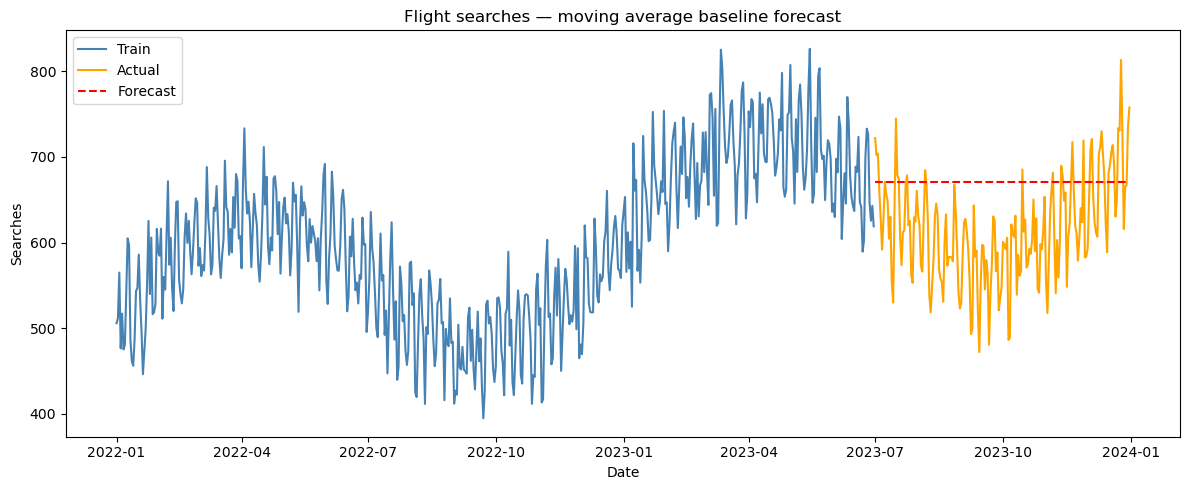

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(train['date'], train['searches'], label='Train', color='steelblue')
plt.plot(test['date'], test['searches'], label='Actual', color='orange')
plt.plot(test['date'], test['forecast'], label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Flight searches — moving average baseline forecast')
plt.xlabel('Date')
plt.ylabel('Searches')
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(test['searches'], test['forecast'])
mape = mean_absolute_percentage_error(test['searches'], test['forecast'])
rmse = np.sqrt(np.mean((test['searches'] - test['forecast'])**2))

print(f"MAE:  {mae:.1f} searches")
print(f"MAPE: {mape*100:.1f}%")
print(f"RMSE: {rmse:.1f} searches")

MAE:  69.0 searches
MAPE: 11.9%
RMSE: 82.0 searches


In [37]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['searches'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("Series is stationary — good to go")
else:
    print("Series is not stationary — needs differencing")

ADF Statistic: -1.0892
P-value: 0.7194
Series is not stationary — needs differencing
